## Backprop Drill
## Refs
- [video lecture](https://www.youtube.com/watch?v=q8SA3rM6ckI&list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&index=5)
- [you should know backprop](https://karpathy.medium.com/yes-you-should-understand-backprop-e2f06eab496b)
- [batchnorm paper](https://arxiv.org/pdf/1502.03167)
- [starter code](https://colab.research.google.com/drive/1WV2oi2fh9XXyldh02wupFQX0wh5ZC-z-?usp=sharing)
- [wolframalpha](https://www.wolframalpha.com/input?i=d%28lnx%29%2Fdx)
- [Bessel's Correction](https://math.oxford.emory.edu/site/math117/besselCorrection/)
- [lecture jupyter](https://github.com/karpathy/nn-zero-to-hero/blob/master/lectures/makemore/makemore_part4_backprop.ipynb)

## Implementation 
### Batch Norm
In batchnorm paper, the authors implement batch norm in 2 ways. For training, they use biased estimation for computing variance. But in inference they use unbiased estimation. 
- training (biased)
    - divided by n:  1/(n)*(bndiff2).sum(0, keepdim=True)
- inference (unbiased)
    - divided by n-1: 1/(n-1)*(bndiff2).sum(0, keepdim=True)
 
Karpathy's implementataion only uses unviased estimation. It is reasonable because each batch norm only has 32 (sample size) observations from populationm, it is relatively small so we should use unbiased estimation.

Kparpathy thinks the discrepency between training and iference's implementation from paper is a bug. We should use consistent method for computing sample variacne. So the optimal solution is unbiased estimation (n - 1)

pytorch
- [torch.var](https://docs.pytorch.org/docs/stable/generated/torch.var.html#torch-var)
    - param `correction = 1`: unbiased estimation
- [BatchNorm1d](https://docs.pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html#batchnorm1d)
    - Same as paper, train with biased estimated variacne, infer with unbiased estimated variance

In [2]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [3]:
# read in all the words
words = open('./assets/names.txt', 'r').read().splitlines()
print(len(words))
print(max(len(w) for w in words))
print(words[:8])

32033
15
['emma', 'olivia', 'ava', 'isabella', 'sophia', 'charlotte', 'mia', 'amelia']


In [4]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
vocab_size = len(itos)
print(itos)
print(vocab_size)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}
27


In [5]:
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  
  for w in words:
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr,  Ytr  = build_dataset(words[:n1])     # 80%
Xdev, Ydev = build_dataset(words[n1:n2])   # 10%
Xte,  Yte  = build_dataset(words[n2:])     # 10%

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [6]:
# utility function we will use later when comparing manual gradients to PyTorch gradients
def cmp(s, dt, t):
  # return single bool value as <class 'torch.Tensor'> 
  ex = torch.all(dt == t.grad).item()
  # return single bool value as <class 'bool'>, compare to floating point so it is approxmiately equality.
  app = torch.allclose(dt, t.grad)
  maxdiff = (dt - t.grad).abs().max().item()
  print(f'{s:15s} | exact: {str(ex):5s} | approximate: {str(app):5s} | maxdiff: {maxdiff}')

## Params
- Normally, we initialzie bias with 0, but in this practice, we initialize it with small number. The zero biases intializaiton will mask the errors caused by wrong gradient implementation.
- The b1 in not necessary, since linear-layer1 is followed by batcnhnorm layer. But we still have b1 for gradient practice purpose.


In [7]:
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 64 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1 # using b1 just for fun, it's useless because of BN
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

# Note: I am initializating many of these parameters in non-standard ways
# because sometimes initializating with e.g. all zeros could mask an incorrect
# implementation of the backward pass.

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

4137


In [8]:
batch_size = 32
n = batch_size # a shorter variable also, for convenience
# construct a minibatch
ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y

In [9]:
# forward pass, "chunkated" into smaller steps that are possible to backward one at a time

emb = C[Xb] # embed the characters into vectors
embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
# Linear layer 1
hprebn = embcat @ W1 + b1 # hidden layer pre-activation
# BatchNorm layer
bnmeani = 1/n*hprebn.sum(0, keepdim=True)
bndiff = hprebn - bnmeani
bndiff2 = bndiff**2
bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
bnvar_inv = (bnvar + 1e-5)**-0.5
bnraw = bndiff * bnvar_inv
hpreact = bngain * bnraw + bnbias
# Non-linearity
h = torch.tanh(hpreact) # hidden layer
# Linear layer 2
logits = h @ W2 + b2 # output layer
# cross entropy loss (same as F.cross_entropy(logits, Yb))
logit_maxes = logits.max(1, keepdim=True).values
norm_logits = logits - logit_maxes # subtract max for numerical stability (if some logits is too large, then the norm_logits.exp() will cause error)
counts = norm_logits.exp()
counts_sum = counts.sum(1, keepdims=True)
counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
probs = counts * counts_sum_inv
logprobs = probs.log()
loss = -logprobs[range(n), Yb].mean()

# PyTorch backward pass
for p in parameters:
  p.grad = None
for t in [logprobs, probs, counts, counts_sum, counts_sum_inv, # afaik there is no cleaner way
          norm_logits, logit_maxes, logits, h, hpreact, bnraw,
         bnvar_inv, bnvar, bndiff2, bndiff, hprebn, bnmeani,
         embcat, emb]:
  t.retain_grad()
loss.backward()
loss

tensor(3.3456, grad_fn=<NegBackward0>)

In [10]:
logprobs.shape

torch.Size([32, 27])

## Explanation

### Background
- If both numerator and demoniator have same dimension, then it works just like scalar. 
### Each Element
dlogprobs (32, 27)
- The derivative of loss with respect to logprobs
    - $\frac{dL}{dlogprobs}$ 
- In each row, only the cell of selected (labeled) column contributes to loss.
    - The elemnt contributes to loss thorugh addition.
        - $\frac{-1}{n}(a + b + c) = L$
        - $\frac{dL}{da} = \frac{-1}{n}$
dprobs (32, 27)
- The derivative of loss with respect to probs
    - $\frac{dL}{dprobs} = \frac{dlogprobs}{dprobs} * \frac{dL}{dlogprobs}$
        - $\frac{dlogprobs}{dprobs}$: local gradient
- local gradient
    - $\frac{dln(a)}{da} = \frac{1}{a}$

dcounts_sum_inv (32, 1) (broadcasting during operation)
- The derivative of loss with respect to counts_sum_inv
    - $\frac{dL}{d\text{counts\_sum\_inv}} = \frac{dprobs}{\text{dcounts\_sum\_inv}} * \frac{dL}{dprobs}$
- local gradient
    - $\frac{dprobs}{\text{dcounts\_sum\_inv}}$
        - Point1 
            - Background
                - a: counts
                - b: counts_sum_inv
                - c: probs
            - a * b = c
                - $\frac{dc}{db} = a$
        - Point2
            - Background
                - $p_{ij}$: probs
                - $s_i$: counts_sum_inv
                - $c_{ij}: counts$ 
            - $ \frac{\partial L}{\partial s_i} = \sum_{j} \frac{\partial p_{ij}}{\partial s_i} \cdot \frac{\partial L}{\partial p_{ij}}$
                - $\frac{\partial p_{ij}}{\partial s_i} = c_{ij}$
                    - $\frac{\partial L}{\partial s_i} = \sum_{j} c_{ij} *  \frac{\partial L}{\partial p_{ij}}$
- Result
    - $\frac{dL}{d\text{counts\_sum\_inv}} = \sum_{j} \text{counts} * \frac{dL}{dprobs}$

dcounts (32, 27)
    - Same shape, so it is just derivative of multplication operation result.

dcounts_sum (32, 1)
- The derivative of loss with respect to dcounts_sum
    - $\frac{dL}{d\text{dcounts\_sum}} = \frac{dcounts\_sum\_inv}{\text{dcounts\_sum}} * \frac{dL}{\text{dcounts\_sum\_inv}}$
- Local gradient: $\frac{dcounts\_sum\_inv}{\text{dcounts\_sum}}$
    - $\frac{d\frac{1}{x}}{dx} = -\frac{1}{x^2}$

dcounts (32, 27)
- The derivative of loss with respect to dcounts
    - $\frac{dL}{d\text{dcounts}} = \frac{dcounts\_sum}{\text{dcounts}} * \frac{dL}{\text{dcounts\_sum}}$
- Local gradient:
```
a11 a12 a13       b1 = a11 + a12 + a13
a21 a22 a23   ->  b2 = a21 + a22 + a23
a31 a32 a33       b3 = a31 + a32 + a33
```
Take the 1st row as example, the derivative of `b1` with respect to `a1j` = 1. So basically, in backward path, we can think it as the $\frac{dL}{db1}$ just flow through 3 subpath (a11, a12, a13) so the derivative of `L` with respect to each of them is just $\frac{dL}{db1}$.

So in our case, we just need to expand dcounts_sum (32,1) to (32,27)

dnorm_logits (32, 27)
- The derivative of loss with respect to dcounts
    - $\frac{dL}{d\text{dnorm\_logits}} = \frac{dcounts}{\text{dnorm\_logits}} * \frac{dL}{\text{dcounts}}$
- Local gradient:
    - $\frac{de^{x}}{dx} = e^{x}$
    - $\frac{dcounts}{\text{dnorm\_logits}} = counts

dlogits (32, 27) (part 1)
- Elements (norm_logits = logits - logit_maxes)
    - logits (32, 27)
    - logit_maxes (32,1)
    - norm_logits (32, 27)
- The derivative of loss with respect to logits
    - $\frac{dL}{d\text{logits}} = \frac{dnorm\_logits}{\text{dlogits}} * \frac{dL}{\text{norm\_logits}}$
- Local gradient:
```
c11 c12 c13       a11 + a12 + a13  - b1 (broadcasting)
c21 c22 c23   ->  a21 + a22 + a23  - b1
c31 c32 c33       a31 + a32 + a33  - b1
```
- ()
    - c = a - b
    - $\frac{dc}{da} = 1$
    - The local gradient is 1

dlogit_maxes (32, 1)
- Elements (norm_logits = logits - logit_maxes)
    - logits (32, 27)
    - logit_maxes (32,1)
    - norm_logits (32, 27)
- The derivative of loss with respect to `logit_maxes`
    - multiplication involves broadcasting + summing over j
$$
\frac{\partial L}{\partial \text{logit\_maxes}_i}
=
\sum_{j}
\frac{\partial L}{\partial \text{norm\_logits}_{ij}}
\cdot
\frac{\partial \text{norm\_logits}_{ij}}{\partial \text{logit\_maxes}_i}
$$

- Local gradient:
```
c11 c12 c13       a11 + a12 + a13  - b1 (broadcasting)
c21 c22 c23   ->  a21 + a22 + a23  - b1
c31 c32 c33       a31 + a32 + a33  - b1
```
- ()
    - Go thourgh broadcasting, so we can see the backward propagation in each row 3 columns are flow through single column. So we should sum the gradietns of each row to get aggregated sum of gradients.
    - c = a - b
        - $\frac{dc}{db} = -1$
- note
    - In mathematic analytic, `norm_logits = logits - logit_maxes` actually does not change the result of `probs`. It is just a safe guard to prevent overflow if some value is too large. So the gradients should be 0
        - We can see that dlogit_maxes has extreme small number so it works as 0. So we just prove that even we just calculate mathematically step by step (backward), we can still get really close to mathematic theory.


dlogits (32, 27) (part 2) 
- Forward: `logit_maxes = logits.max(1, keepdim=True).values`
- The derivative of loss with respect to logits
    - $\frac{dL}{d\text{logits}} = \frac{logit\_maxes}{\text{dlogits}} * \frac{dL}{\text{logit\_maxes}}$
- Local gradient
    - Since we only take max value in a row and do it row by row. In backward propagation the upstream gradients just flow through those specific places.
 
dh, dW2, db2 `(torch.Size([32, 64]), torch.Size([64, 27]), torch.Size([27]))`
<img src="./assets/derivative-of-matrix-multiplication-addition.jpg" style="max-width: 600px">

- dh = $\text{dlogit} \cdot W_2^{T}$
    - (32, 64) = (32, 27) (27, 64)
- dW2 = $ h_2^{T} \cdot \text{dlogit}$
    - (64, 27) = (64, 32) (32, 27)
- db2 = dlogits.sum(dim = 0)

dhpreact (32, 64)
- forward:
    - h = torch.tanh(hpreact) 
- The derivative of tanh
    - t = tanh(x)
    - $\frac{dt}{dx} = 1 - t^2$
- $\frac{dL}{dhpreact} = \frac{dh}{dhpreact} \frac{dL}{dh}$
    - $(1 - \text{hpreact}^2) * \frac{dL}{dh}$

dbngain, dbnraw, dbnbias
- forward
    - hpreact = bngain * bnraw + bnbias 
- elements:
    - hpreact, bngain, bnraw, bnbias (torch.Size([32, 64]),torch.Size([1, 64]),torch.Size([32, 64]),torch.Size([1, 64]))
- dngain (1, 64)
    - the elemnt-wise multiplication just be treated as scalar in gradient calculation
        - c = a * b, $\frac{dc}{da} = b$
        - hpreact = bngain * bnraw + bnbias
            - local gradient: $\frac{hpreact}{dbngain} = bnraw$
            - previous acuumulated gradient: dhpreact
            - bnraw * dhpreact (32, 64), but the dngain should be 2-dim (1, 64) so we have sum it with dim = 0 (collapse rows)
- dbnraw (32, 64)
    - $\frac{dL}{dbnraw} = \frac{dhpreact}{dbnraw} * \frac{dL}{dhpreact}$
    - local gradient: $\frac{dhpreact}{dbnraw}$ = bngain (1, 64)
    - upstream gradients: dhpreact (32, 64)
    - The reesult: bngain * dhpreact (elemnt wise, the bngain exapnds with dim = 0)
- bnbias (1, 64)
    - $\frac{dL}{dbnbias} = \frac{dhpreact}{dbnbias} * \frac{dL}{dhpreact}$
    - 1 * dhpreact (32, 64)
    - In forward propagation, bnbias expands with dim = 0 from (1, 64) (broadcasting)
        - So we need  (1 * dhpreact).sum(dim = 0, keepdim = True) (collapse)


bnraw = bndiff * bnvar_inv
- elements
    - bnraw.shape, bndiff.shape, bnvar_inv.shape (torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))
dbndiff (32, 64) (part 1)
- Derivative of L with respect to `bndiff`
    - $\frac{dL}{dbndiff} = \frac{dbnraw}{bndiff} * \frac{dL}{dbnraw}$
- Local gradient
    - $\frac{dbnraw}{bndiff}$ = bnvar_inv (1, 64)
- Result
    -  bnvar_inv (1, 64) * dbnraw (32, 64) -> bnvar_inv boradcasting along rows (dim = 0)
dbnvar_inv (1, 64)
- Derivative of L with respect to `bndiff`
    - $\frac{dL}{dbnvar\_inv} = \frac{dbnraw}{dbnvar\_inv} * \frac{dL}{dbnraw}$
- Local gradient
    - $\frac{dbnraw}{dbnvar\_inv}$ = bndiff (32, 64)
- Result
    -  bndiff (32, 64) * dbnraw (32, 64)
    -  In forwardprop, dbnvar_inv wnet thorough broadcasting (expands rows) to do element wise multiplication, so in reverse we need to collapse rows.
    -  (bndiff (32, 64) * dbnraw (32, 64)).sum(dim = 0, keepdim = True)

dbnvar (1, 64)
- forward
    - bnvar_inv = (bnvar + 1e-5)**-0.5 
- Derivative of L with respect to `bndiff`
    - $\frac{dL}{dbnvar} = \frac{dbnvar_inv}{dbnvar} * \frac{dL}{dbnvar_inv}$
- Local gradient
    - $\frac{dbnvar_inv}{dbnvar} = \frac{d \sqrt{x + \epsilon}}{x + \epsilon} * \frac{d (x + \epsilon)}{dx} = -0.5 * (x + \epsilon)^{-1.5}$
- Result
    - $-0.5 * (\text{bnvar} + \epsilon)^{-1.5} * \text{dbnvar\_inv}$


bbndiff2 (32, 64)
- Elements
    - bnvar.shape, bndiff2.shape ((torch.Size([1, 64]), torch.Size([32, 64]))) 
- Forward 
    - bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True)
    - row collapsing (sum over column)
        - In backward propgation, we need to reverse it so we need broadcasting 
- Derivative of L with `bndiff2`
    - $\frac{dL}{dbndiff2} = \frac{ddbnvar}{dbndiff2} * \frac{dL}{ddbnvar}$
- Local gradient
    - $\frac{ddbnvar}{dbndiff2}$
        - $\frac{db1}{da11} = \frac{1}{n-1}$
        - $\frac{db1}{da21} = \frac{1}{n-1}$
        - $\frac{db2}{da12} = \frac{1}{n-1}$
        - $\frac{db2}{da22} = \frac{1}{n-1}$

```
B = [b1, b2]
A = 
a11 a12
a21 a22

B = (1/(n-1) * A).sum(dim = 0, keepdim = True)
b1 = (1 / (n - 1)) (a11 + a21)
b2 = (1 / (n - 1)) (a12 + a22)
```
So basically, we need a matrix has same shape as bndiff2 (32, 64) and all entries should be $\frac{1}{n-1}$

- Result
    - (32, 64) matrix X *  dbnvar (1, 64)
        - dbnvar will be broadasting over column (dim = 0, expands the row (broadcast), which is the reverse of collapsing)
     
dbndiff (32, 64)  (part2, `+=`)
- Elements
    - bndiff2.shape, bndiff.shape (torch.Size([32, 64]), torch.Size([32, 64]))
- Forward
    - bndiff2 = bndiff**2 
- Derivative of L with respect to `bndiff`
    - same shapes, so derivative operation is just like working on scalar values. 
    - $\frac{dL}{dbndiff} = \frac{dbndiff2}{dbndiff} * \frac{dL}{dbndiff2}$
- Local gradient
    - Simple as it is just implmenet it.
 

dhprebn (32, 64) (part 1)
- Elements
    -  bndiff.shape, hprebn.shape, bnmeani.shape (torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))
- Forward
    - bndiff = hprebn - bnmeani
- Derivative of L with respect to `hprebn` 
    - $\frac{dL}{dhprebn} = \frac{dbndiff}{dhprebn} * \frac{dL}{bbndiff}$
- Local gradient
    - $\frac{dbndiff}{dhprebn} = \text{matrix 1 with shape [32, 64]}$, both elements have same shape so it works like scalar value
- Result
    - matrix with 1 (32, 64) * dbndiff = dbndiff

dbnmeani (1, 64)
- Elements
    -  bndiff.shape, hprebn.shape, bnmeani.shape (torch.Size([32, 64]), torch.Size([32, 64]), torch.Size([1, 64]))
- Forward
    - bndiff = hprebn - bnmeani
    - The bnmeani boradcasts with dim = 0, exapnds rows (expand over columns) (in backward we need to sum over columns, collapses rows (dim = 0))
- Derivative of L with respect to `bnmeani` 
    - $\frac{dL}{dbnmeani} = \frac{dbndiff}{dbnmeani} * \frac{dL}{bbndiff}$
- Local gradient
    - $\frac{dbndiff}{dbnmeani} = \text{matrix with shape (32, 64) and all entires is -1}$
- Result
    - \[(matrix with shape (32, 64) and all entires is -1) * dbndiff(32, 64)\].sum(dim = 0, keepdim= True)
        - sum: collapse rows
     
dhprebn (32, 64) (part2)
- Elements
    - bnmeani.shape, hprebn.shape
    - (torch.Size([1, 64]), torch.Size([32, 64]))
- forward propagation
    - `bnmeani = 1/n*hprebn.sum(0, keepdim=True)`
        - hprebn collapses rows
        - sum over rows (vertically)
- backwarod propagation
    - need broadcasting over rows
- Derivative of L with respect to `hprebn`
    - $\frac{dL}{dhprebn} = \frac{dbnmeani}{dhprebn} * \frac{dL}{dbnmeani}$ 
- Local gradient
    - $\frac{ebnmeani}{dhprebn} = \frac{1}{n}$ and do the broadcasting in the end
- Result:
    - $(\frac{1}{n}\text{.broadcasting}) * \text{dbnmeani}$

dembact, dW1, db1 <br/>
<img src="./assets/derivative-of-matrix-multiplication-addition.jpg" style="max-width: 600px">
- Elements
    - hprebn.shape, embcat.shape, W1.shape, b1.shape
    - (torch.Size([32, 64]), torch.Size([32, 30]), torch.Size([30, 64]), torch.Size([64]))
- Forward Propagation
    - `hprebn = embcat @ W1 + b1`
dembact (32, 30)
- Gradient
    - `dhprebn @ W1.T`
dW1 (30, 64)
- Gradient
    - `embcat.T @ dhprebn`
db1 (64, )
- Forward propagation
    - broadcast over rows (dim = 0) (vertically)
- Backward propagation
    - collapse over rows (dim = 0) 
- Gradient
     - `dhprebn.sum(dim = 0, keepdim = True)`
 
demb
- elements
    - embcat.shape, emb.shape
    - (torch.Size([32, 30]), torch.Size([32, 3, 10]))
- forward propagation
    - `embcat = emb.view(emb.shape[0], -1)`
    - change dimension to (32, 3, 30)
- backward propagation
    - change dimesnion back to (32, 3, 10)
- gradients
    - `dembcat.view(emb.shape)`

dC
- elements
    - emb.shape, C.shape, Xb.shape
    - (torch.Size([32, 3, 10]), torch.Size([27, 10]), torch.Size([32, 3]))
- Forward propagation
    - emb = C[Xb]
- Backward propagation
    - Add the gradients accumulatively to designated embedding row

In [11]:
emb.shape, C.shape, Xb.shape

(torch.Size([32, 3, 10]), torch.Size([27, 10]), torch.Size([32, 3]))

In [12]:
# Exercise 1: backprop through the whole thing manually, 
# backpropagating through exactly all of the variables 
# as they are defined in the forward pass above, one by one

# -----------------
# YOUR CODE HERE :)
dlogprobs = torch.zeros_like(logprobs)
dlogprobs[range(n), Yb] = -1.0 / n
dprobs = (1.0 / probs) * dlogprobs 
dcounts_sum_inv = (counts * dprobs).sum(1, keepdim = True)
dcounts = counts_sum_inv * dprobs
dcounts_sum = (-counts_sum**-2) * dcounts_sum_inv
# += because there are 2 paths of it
dcounts += torch.ones_like(counts) * dcounts_sum
dnorm_logits = counts * dcounts
dlogit_maxes = -dnorm_logits.sum(1, keepdim = True) 
dlogits = dnorm_logits.clone()
# We don't need to keep dim here, we just need to pass a list to it.
dlogits += F.one_hot(logits.max(dim = 1).indices, num_classes = logits.shape[1]) * dlogit_maxes
# also: dh = dlogits @ W2.T
dh = torch.matmul(dlogits, W2.t())
dW2 = h.T @ dlogits
db2 = dlogits.sum(dim = 0)
dhpreact = (1.0 - h**2) * dh
dbngain = (bnraw * dhpreact).sum(dim = 0, keepdim= True)
dbnraw = bngain * dhpreact
dbnbias = (1 * dhpreact).sum(dim = 0, keepdim = True)
dbndiff = bnvar_inv * dbnraw # part 1
dbnvar_inv = (bndiff * dbnraw).sum(dim = 0, keepdim = True)
dbnvar = -0.5 * (bnvar + 1e-5)**-1.5 * dbnvar_inv
dbndiff2 = (1.0 / (n - 1)) * torch.ones_like(bndiff2) * dbnvar
dbndiff += (2 * bndiff) * dbndiff2
dhprebn = dbndiff.clone()
# Karpathy do not k
dbnmeani = (-dbndiff).sum(dim = 0, keepdim = True)
dhprebn += (1.0 / n) * torch.ones_like(hprebn) * dbnmeani
dembcat = dhprebn @ W1.T
dW1 = embcat.T @ dhprebn
db1 = dhprebn.sum(dim = 0, keepdim = True)
demb = dembcat.view(emb.shape)

dC = torch.zeros_like(C)
# m-th example
for m in range(demb.shape[0]):
    # context index in m-th example
    for cti in range(demb.shape[1]):
        # grads for the embedding row of the context index in m-th example
        grads = demb[m, cti]
        # char_index
        chr_i = Xb[m, cti] 
        dC[chr_i] += grads
# -----------------

cmp('logprobs', dlogprobs, logprobs)
cmp('probs', dprobs, probs)
cmp('counts_sum_inv', dcounts_sum_inv, counts_sum_inv)
cmp('counts_sum', dcounts_sum, counts_sum)
cmp('counts', dcounts, counts)
cmp('norm_logits', dnorm_logits, norm_logits)
cmp('logit_maxes', dlogit_maxes, logit_maxes)
cmp('logits', dlogits, logits)
cmp('h', dh, h)
cmp('W2', dW2, W2)
cmp('b2', db2, b2)
cmp('hpreact', dhpreact, hpreact)
cmp('bngain', dbngain, bngain)
cmp('bnbias', dbnbias, bnbias)
cmp('bnraw', dbnraw, bnraw)
cmp('bnvar_inv', dbnvar_inv, bnvar_inv)
cmp('bnvar', dbnvar, bnvar)
cmp('bndiff2', dbndiff2, bndiff2)
cmp('bndiff', dbndiff, bndiff)
cmp('bnmeani', dbnmeani, bnmeani)
cmp('hprebn', dhprebn, hprebn)
cmp('embcat', dembcat, embcat)
cmp('W1', dW1, W1)
cmp('b1', db1, b1)
cmp('emb', demb, emb)
cmp('C', dC, C)

logprobs        | exact: True  | approximate: True  | maxdiff: 0.0
probs           | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum_inv  | exact: True  | approximate: True  | maxdiff: 0.0
counts_sum      | exact: True  | approximate: True  | maxdiff: 0.0
counts          | exact: True  | approximate: True  | maxdiff: 0.0
norm_logits     | exact: True  | approximate: True  | maxdiff: 0.0
logit_maxes     | exact: True  | approximate: True  | maxdiff: 0.0
logits          | exact: True  | approximate: True  | maxdiff: 0.0
h               | exact: True  | approximate: True  | maxdiff: 0.0
W2              | exact: True  | approximate: True  | maxdiff: 0.0
b2              | exact: True  | approximate: True  | maxdiff: 0.0
hpreact         | exact: False | approximate: True  | maxdiff: 4.656612873077393e-10
bngain          | exact: False | approximate: True  | maxdiff: 1.862645149230957e-09
bnbias          | exact: False | approximate: True  | maxdiff: 2.7939677238464355e-09
bnraw  

I haven't figured it out why start from hpreact I only get approxmate True. Although numerically, it is still correct. But karpathy got all exact True.

In [96]:
logits.shape

torch.Size([32, 27])

In [14]:
dbndiff.shape, dbnmeani.shape

(torch.Size([32, 64]), torch.Size([1, 64]))

## Exercise 2
We can mathematically derive the formula of derivative of Loss with respect to loss direclty, so that we can skip all those macro steps.

### Fromula
#### Loss
$p_i = \frac{e^{l_i}}{\sum_j e^{l_j}}$  <br/>
$loss = -log(p_y) = -log(\frac{e^{l_y}}{\sum_j e^{l_j}})$
- y: the label index
- j: all indices (27 indices)

#### [Derivation](https://youtu.be/q8SA3rM6ckI?list=PLAqhIrjkxbuWI23v9cThsA9GvCAUhRvKZ&t=5452)
$\frac{d L}{d l_i} = \frac{d (-log(\frac{e^{l_y}}{\sum_j e^{l_j}}))}{d l_i}$
Results
- $i != y$
    - $p_i - 0 = p_i$
 
- $i = y$
    - $p_i - 1$


## Note
- The loss of a batch, is the average loss of the whole batch.
    - Sum loss of each row and divied it by batch_size

In [97]:
# Exercise 2: backprop through cross_entropy but all in one go
# to complete this challenge look at the mathematical expression of the loss,
# take the derivative, simplify the expression, and just write it out

# forward pass

# before:
# logit_maxes = logits.max(1, keepdim=True).values
# norm_logits = logits - logit_maxes # subtract max for numerical stability
# counts = norm_logits.exp()
# counts_sum = counts.sum(1, keepdims=True)
# counts_sum_inv = counts_sum**-1 # if I use (1.0 / counts_sum) instead then I can't get backprop to be bit exact...
# probs = counts * counts_sum_inv
# logprobs = probs.log()
# loss = -logprobs[range(n), Yb].mean()

# now:
loss_fast = F.cross_entropy(logits, Yb)
print(loss_fast.item(), 'diff:', (loss_fast - loss).item())

3.335184335708618 diff: 0.0


In [98]:
# backward pass

dlogits = F.softmax(logits, 1)
dlogits[range(n), Yb] -= 1
# Since the loss is average loss over batch observations, we also need to scale down our gradients
dlogits /= n

cmp('logits', dlogits, logits) # I can only get approximate to be true, my maxdiff is 6e-9

logits          | exact: False | approximate: True  | maxdiff: 5.820766091346741e-09


### Takeaways
Why sum of gradients is zero
- Mathematic
    - Sum of Gradients: $\sum_j p_j - y_j = \sum_j p_j - \sum_j y_j = 1 - 1 = 0$ 
- Intuition
    - Both increaseing and decreasing magnitude should be balance. Model increase the probability of labeld index, should decrease the same amount of probabiltiy among other non-labeled indeices. The magnitude is based on the softmax probability distribution.

<hr/>
 
Why labled gradient is negative and non-labeled gradietn are same as its softmax probability <br/>
Gradient: $p_j - y_j$ (we derive this formula mathematically)
- labeled logits
    - 0.0192 - 1 = -0.9808
- non-labeled logits
    -  $p_j - 0 = p_j$ 

<hr/>
Why negative gradient means increaseing the probability of labeled logits. (Here `z` means the probability of softmax distribution)

intuition
$\frac{\partial L}{\partial z} < 0$ means increase z a bit (labeld logits), the loss decreases. So it would be better to increase the value of z.
mathematic
gradient descent formula is $z_{\text{new}} = z - \frac{\partial L}{\partial z}$ <br/>
So, if the gradietn is negative then the z increases.

In [99]:
print('Softmax probabiltiy for firt row: \n', F.softmax(logits, 1)[0])
print('Scale gradients of first row: \n', dlogits[0] * n)
print('Label index: \n', Yb[0])
print('Sum of the scaled gradients of first row: \n', (dlogits[0] * n).sum())

Softmax probabiltiy for firt row: 
 tensor([0.0701, 0.0929, 0.0172, 0.0457, 0.0175, 0.0773, 0.0243, 0.0362, 0.0191,
        0.0334, 0.0388, 0.0403, 0.0373, 0.0285, 0.0364, 0.0132, 0.0085, 0.0204,
        0.0160, 0.0532, 0.0474, 0.0220, 0.0256, 0.0720, 0.0583, 0.0263, 0.0222],
       grad_fn=<SelectBackward0>)
Scale gradients of first row: 
 tensor([ 0.0701,  0.0929,  0.0172,  0.0457,  0.0175,  0.0773,  0.0243,  0.0362,
        -0.9809,  0.0334,  0.0388,  0.0403,  0.0373,  0.0285,  0.0364,  0.0132,
         0.0085,  0.0204,  0.0160,  0.0532,  0.0474,  0.0220,  0.0256,  0.0720,
         0.0583,  0.0263,  0.0222], grad_fn=<MulBackward0>)
Label index: 
 tensor(8)
Sum of the scaled gradients of first row: 
 tensor(-5.9605e-08, grad_fn=<SumBackward0>)


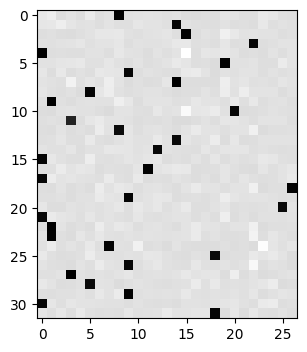

In [100]:
plt.figure(figsize=(4, 4))
plt.imshow(dlogits.detach(), cmap='gray')

## Exercies 3

- All 64 neurson should go through the formula derived from the mathmatically analysis.

In [101]:
# Exercise 3: backprop through batchnorm but all in one go
# to complete this challenge look at the mathematical expression of the output of batchnorm,
# take the derivative w.r.t. its input, simplify the expression, and just write it out
# BatchNorm paper: https://arxiv.org/abs/1502.03167

# forward pass

# before:
# bnmeani = 1/n*hprebn.sum(0, keepdim=True)
# bndiff = hprebn - bnmeani
# bndiff2 = bndiff**2
# bnvar = 1/(n-1)*(bndiff2).sum(0, keepdim=True) # note: Bessel's correction (dividing by n-1, not n)
# bnvar_inv = (bnvar + 1e-5)**-0.5
# bnraw = bndiff * bnvar_inv
# hpreact = bngain * bnraw + bnbias

# now:
hpreact_fast = bngain * (hprebn - hprebn.mean(0, keepdim=True)) / torch.sqrt(hprebn.var(0, keepdim=True, unbiased=True) + 1e-5) + bnbias
print('max diff:', (hpreact_fast - hpreact).abs().max())

max diff: tensor(7.1526e-07, grad_fn=<MaxBackward1>)


In [102]:
# backward pass

# before we had:
# dbnraw = bngain * dhpreact
# dbndiff = bnvar_inv * dbnraw
# dbnvar_inv = (bndiff * dbnraw).sum(0, keepdim=True)
# dbnvar = (-0.5*(bnvar + 1e-5)**-1.5) * dbnvar_inv
# dbndiff2 = (1.0/(n-1))*torch.ones_like(bndiff2) * dbnvar
# dbndiff += (2*bndiff) * dbndiff2
# dhprebn = dbndiff.clone()
# dbnmeani = (-dbndiff).sum(0)
# dhprebn += 1.0/n * (torch.ones_like(hprebn) * dbnmeani)

# calculate dhprebn given dhpreact (i.e. backprop through the batchnorm)
# (you'll also need to use some of the variables from the forward pass up above)

# -----------------
# YOUR CODE HERE :)
dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0)) # TODO. my solution is 1 (long) line
# -----------------

cmp('hprebn', dhprebn, hprebn) # I can only get approximate to be true, my maxdiff is 9e-10

hprebn          | exact: False | approximate: True  | maxdiff: 9.313225746154785e-10


## Exercise 4

In [107]:
# Exercise 4: putting it all together!
# Train the MLP neural net with your own backward pass

# init
n_embd = 10 # the dimensionality of the character embedding vectors
n_hidden = 200 # the number of neurons in the hidden layer of the MLP

g = torch.Generator().manual_seed(2147483647) # for reproducibility
C  = torch.randn((vocab_size, n_embd),            generator=g)
# Layer 1
W1 = torch.randn((n_embd * block_size, n_hidden), generator=g) * (5/3)/((n_embd * block_size)**0.5)
b1 = torch.randn(n_hidden,                        generator=g) * 0.1
# Layer 2
W2 = torch.randn((n_hidden, vocab_size),          generator=g) * 0.1
b2 = torch.randn(vocab_size,                      generator=g) * 0.1
# BatchNorm parameters
bngain = torch.randn((1, n_hidden))*0.1 + 1.0
bnbias = torch.randn((1, n_hidden))*0.1

parameters = [C, W1, b1, W2, b2, bngain, bnbias]
print(sum(p.nelement() for p in parameters)) # number of parameters in total
for p in parameters:
  p.requires_grad = True

# same optimization as last time
max_steps = 200000
batch_size = 32
n = batch_size # convenience
lossi = []

# use this context manager for efficiency once your backward pass is written (TODO)
with torch.no_grad():

    # kick off optimization
    for i in range(max_steps):
    
      # minibatch construct
      ix = torch.randint(0, Xtr.shape[0], (batch_size,), generator=g)
      Xb, Yb = Xtr[ix], Ytr[ix] # batch X,Y
    
      # forward pass
      emb = C[Xb] # embed the characters into vectors
      embcat = emb.view(emb.shape[0], -1) # concatenate the vectors
      # Linear layer
      hprebn = embcat @ W1 + b1 # hidden layer pre-activation
      # BatchNorm layer
      # -------------------------------------------------------------
      bnmean = hprebn.mean(0, keepdim=True)
      bnvar = hprebn.var(0, keepdim=True, unbiased=True)
      bnvar_inv = (bnvar + 1e-5)**-0.5
      bnraw = (hprebn - bnmean) * bnvar_inv
      hpreact = bngain * bnraw + bnbias
      # -------------------------------------------------------------
      # Non-linearity
      h = torch.tanh(hpreact) # hidden layer
      logits = h @ W2 + b2 # output layer
      loss = F.cross_entropy(logits, Yb) # loss function
    
      # backward pass
      for p in parameters:
        p.grad = None
      # loss.backward() # use this for correctness comparisons, delete it later!
    
      # manual backprop! #swole_doge_meme
      # -----------------
      # YOUR CODE HERE :)
      dlogits = F.softmax(logits, 1)
      dlogits[range(n), Yb] -= 1
      dlogits /= n
      # 2nd layer backprop
      dh = dlogits @ W2.T
      dW2 = h.T @ dlogits
      db2 = dlogits.sum(0)
      # tanh
      dhpreact = (1.0 - h**2) * dh
      # batchnorm backprop
      dbngain = (bnraw * dhpreact).sum(0, keepdim=True)
      dbnbias = dhpreact.sum(0, keepdim=True)
      dhprebn = bngain*bnvar_inv/n * (n*dhpreact - dhpreact.sum(0) - n/(n-1)*bnraw*(dhpreact*bnraw).sum(0))
      # 1st layer
      dembcat = dhprebn @ W1.T
      dW1 = embcat.T @ dhprebn
      db1 = dhprebn.sum(0)
      # embedding
      demb = dembcat.view(emb.shape)
      dC = torch.zeros_like(C)
      for k in range(Xb.shape[0]):
        for j in range(Xb.shape[1]):
            ix = Xb[k,j]
            dC[ix] += demb[k,j]
        grads = [dC, dW1, db1, dW2, db2, dbngain, dbnbias]
      # -----------------
    
      # update
      lr = 0.1 if i < 100000 else 0.01 # step learning rate decay
      for p, grad in zip(parameters, grads):
        # p.data += -lr * p.grad # old way of cheems doge (using PyTorch grad from .backward())
        p.data += -lr * grad # new way of swole doge TODO: enable
    
      # track stats
      if i % 10000 == 0: # print every once in a while
        print(f'{i:7d}/{max_steps:7d}: {loss.item():.4f}')
      lossi.append(loss.log10().item())
    
      # if i >= 100: # TODO: delete early breaking when you're ready to train the full net
        # break

12297
      0/ 200000: 3.8024
  10000/ 200000: 2.1942
  20000/ 200000: 2.4093
  30000/ 200000: 2.4860
  40000/ 200000: 1.9719
  50000/ 200000: 2.3842
  60000/ 200000: 2.3818
  70000/ 200000: 2.0646
  80000/ 200000: 2.3824
  90000/ 200000: 2.2346
 100000/ 200000: 1.9443
 110000/ 200000: 2.3654
 120000/ 200000: 1.9728
 130000/ 200000: 2.4247
 140000/ 200000: 2.3026
 150000/ 200000: 2.2234
 160000/ 200000: 1.9780
 170000/ 200000: 1.8471
 180000/ 200000: 1.9690
 190000/ 200000: 1.9158


In [106]:
# useful for checking your gradients
for p,g in zip(parameters, grads):
    cmp(str(tuple(p.shape)), g, p)

(27, 10)        | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08
(30, 200)       | exact: False | approximate: True  | maxdiff: 9.313225746154785e-09
(200,)          | exact: False | approximate: True  | maxdiff: 4.190951585769653e-09
(200, 27)       | exact: False | approximate: True  | maxdiff: 1.4901161193847656e-08
(27,)           | exact: False | approximate: True  | maxdiff: 6.51925802230835e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 3.725290298461914e-09
(1, 200)        | exact: False | approximate: True  | maxdiff: 5.587935447692871e-09


In [108]:
# calibrate the batch norm at the end of training

with torch.no_grad():
  # pass the training set through
  emb = C[Xtr]
  embcat = emb.view(emb.shape[0], -1)
  hpreact = embcat @ W1 + b1
  # measure the mean/std over the entire training set
  bnmean = hpreact.mean(0, keepdim=True)
  bnvar = hpreact.var(0, keepdim=True, unbiased=True)

In [109]:
# evaluate train and val loss

@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 + b1
  hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0700109004974365
val 2.1103875637054443


In [110]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      # forward pass
      emb = C[torch.tensor([context])] # (1,block_size,d)      
      embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
      hpreact = embcat @ W1 + b1
      hpreact = bngain * (hpreact - bnmean) * (bnvar + 1e-5)**-0.5 + bnbias
      h = torch.tanh(hpreact) # (N, n_hidden)
      logits = h @ W2 + b2 # (N, vocab_size)
      # sample
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carlah.
amori.
kif.
jari.
reity.
skaelane.
mahnen.
delynn.
jareei.
ner.
kia.
chaiiv.
kaleigh.
ham.
joce.
quinn.
shoilea.
jadbi.
waterra.
jaryxi.
